<a href="https://colab.research.google.com/github/erigitola/-Random-User--Generator--using--API/blob/main/Daytona_Financial_Performance_Analysis_by_Division.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
# Load General Ledger, Division,& Calendar Dataset
gl = pd.read_csv('/content/GL8.csv')
division = pd.read_csv('/content/Division.csv')
calendar = pd.read_csv('/content/Calendar.csv')

In [3]:
# Preview Dataset
display(gl.head())
display(division.head())
display(calendar.head())

,row_id,transaction_date,division_key,account_key,description,account_name,account_type,nature,amount
0,1,2025-10-01,1,1001,Opening Balance - Buildings,Buildings,"Properties, Plant & Equipment (PPE)",Non-Current Assets,56397548.00
1,2,2025-10-01,1,1003,Opening Balance - Plants & Machineries,Plants & Machineries,"Properties, Plant & Equipment (PPE)",Non-Current Assets,61151562.43
2,3,2025-10-01,1,1004,Opening Balance - Computers & Accessories,Computers & Office Equipment,"Properties, Plant & Equipment (PPE)",Non-Current Assets,11790567.50
3,4,2025-10-01,1,1005,Opening Balance - Motor Vehicle,Motor Vehicle,"Properties, Plant & Equipment (PPE)",Non-Current Assets,24632000.88
4,5,2025-10-01,1,1006,Opening Balance - Furniture & Fittings,Furniture & Fittings,"Properties, Plant & Equipment (PPE)",Non-Current Assets,7834455.38


,division_key,division_name,branch
0,1,Daytona's Assets Long Term,HQ
1,2,Daytona's Liabilities Long Term,HQ
2,3,Daytona's Assets Short Term,HQ
3,4,Daytona's Liabilities Short Term,HQ
4,5,Shareholder's Fund,HQ


,transaction_date,year,month,quarter,day_name
0,2025-10-01,2025,Oct,Q4,Wed
1,2025-10-02,2025,Oct,Q4,Thu
2,2025-10-03,2025,Oct,Q4,Fri
3,2025-10-04,2025,Oct,Q4,Sat
4,2025-10-05,2025,Oct,Q4,Sun


In [7]:

 # Standardize Transaction Date Columns


gl["transaction_date"] = pd.to_datetime(
    gl["transaction_date"],
    format="mixed"
)

calendar["transaction_date"] = pd.to_datetime(
    calendar["transaction_date"],
    format="mixed"
)

In [11]:
# Join General Ledger with Division

merged = gl.merge(
    division,
    on='division_key',
    how='inner'



)

In [12]:
# Join the General Ledger with the Calendar Table

merged = merged.merge(
    calendar,
    on='transaction_date',
    how= 'inner'
)

In [13]:
print(merged.shape)
print(merged.columns.tolist())

(27088, 15)
['row_id', 'transaction_date', 'division_key', 'account_key', 'description', 'account_name', 'account_type', 'nature', 'amount', 'division_name', 'branch', 'year', 'month', 'quarter', 'day_name']


In [16]:
# Validation Join
print("GL Rows:", len(gl))
print("Merged Rows:", len(merged))
print("Unique GL Row IDs:", merged["row_id"].nunique())

GL Rows: 27088
Merged Rows: 27088
Unique GL Row IDs: 27088


In [19]:
print(merged['nature'].unique())

['Non-Current Assets' 'Current Assets' 'Current Liabilities'
 'Non-Current Liabilities' 'Capital' 'Income' 'Expenses']


In [20]:
# Analyze Total Sales by Division

sales_by_division = (
    merged[merged['nature'] == 'Income']
    .groupby('division_name', as_index=False)['amount']
    .sum()
    .sort_values('amount', ascending=False)

)

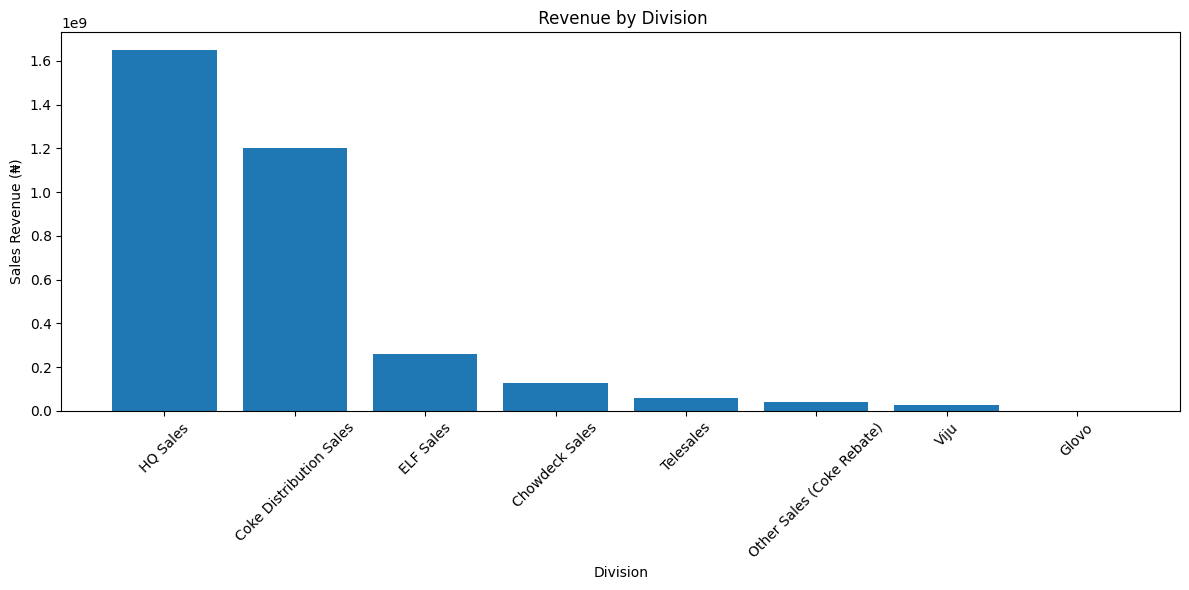

In [31]:


plt.figure(figsize=(12, 6))

plt.bar(
    sales_by_division["division_name"],
    sales_by_division["amount"]
)

plt.title(" Revenue by Division")
plt.xlabel("Division")
plt.ylabel("Sales Revenue (₦)")
plt.xticks(rotation=45)
plt.tight_layout()

# Save chart
plt.savefig(
    "Sales_Revenue_by_Division.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

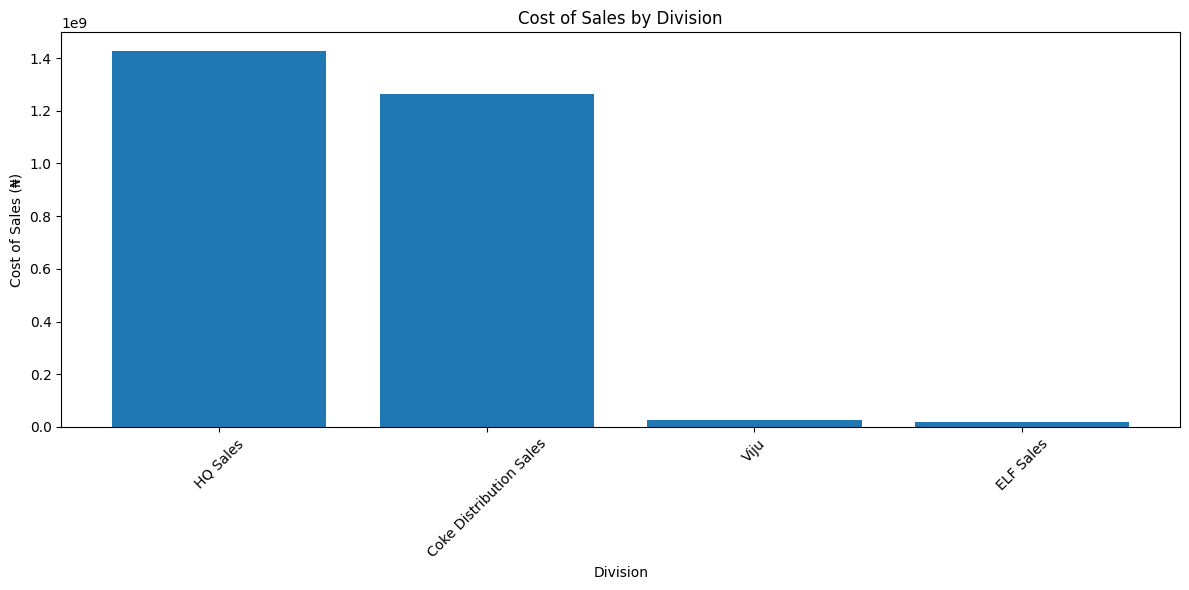

In [30]:


plt.figure(figsize=(12, 6))

plt.bar(
    cost_of_sales["division_name"],
    cost_of_sales["cost_of_sales"]
)

plt.title("Cost of Sales by Division")
plt.xlabel("Division")
plt.ylabel("Cost of Sales (₦)")
plt.xticks(rotation=45)
plt.tight_layout()

# Save chart
plt.savefig(
    "Cost_of_Sales_by_Division.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

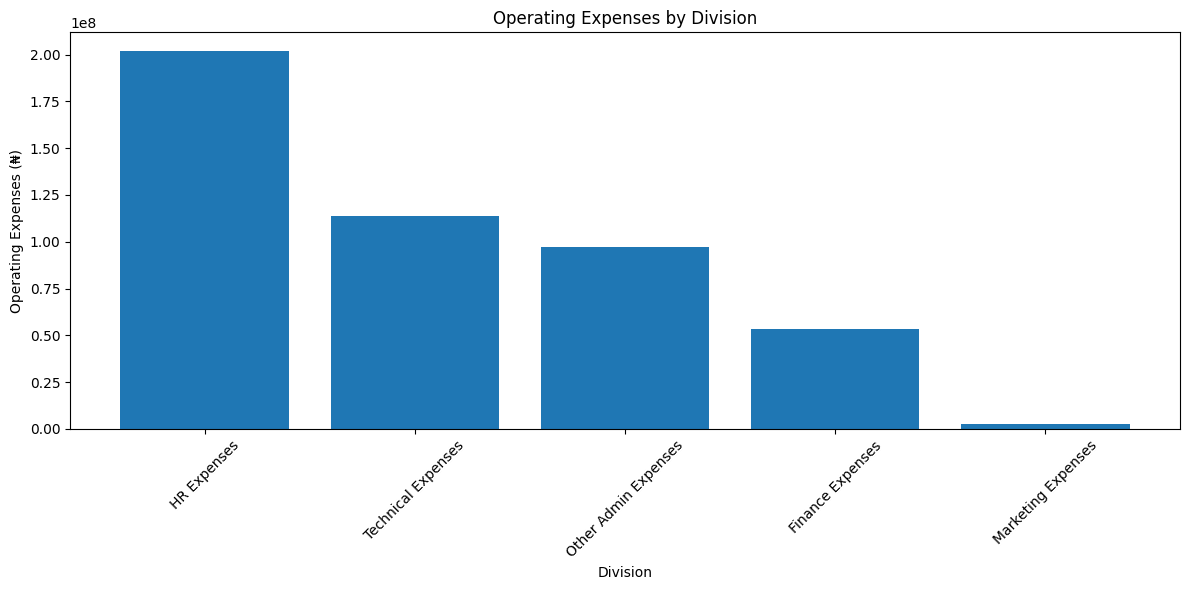

In [32]:

# Save and Display Operating Expenses by Division Chart


plt.figure(figsize=(12, 6))

plt.bar(
    expenses_by_division["division_name"],
    expenses_by_division["operating_expenses"]
)

plt.title("Operating Expenses by Division")
plt.xlabel("Division")
plt.ylabel("Operating Expenses (₦)")
plt.xticks(rotation=45)
plt.tight_layout()

# Save chart
plt.savefig(
    "Operating_Expenses_by_Division.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

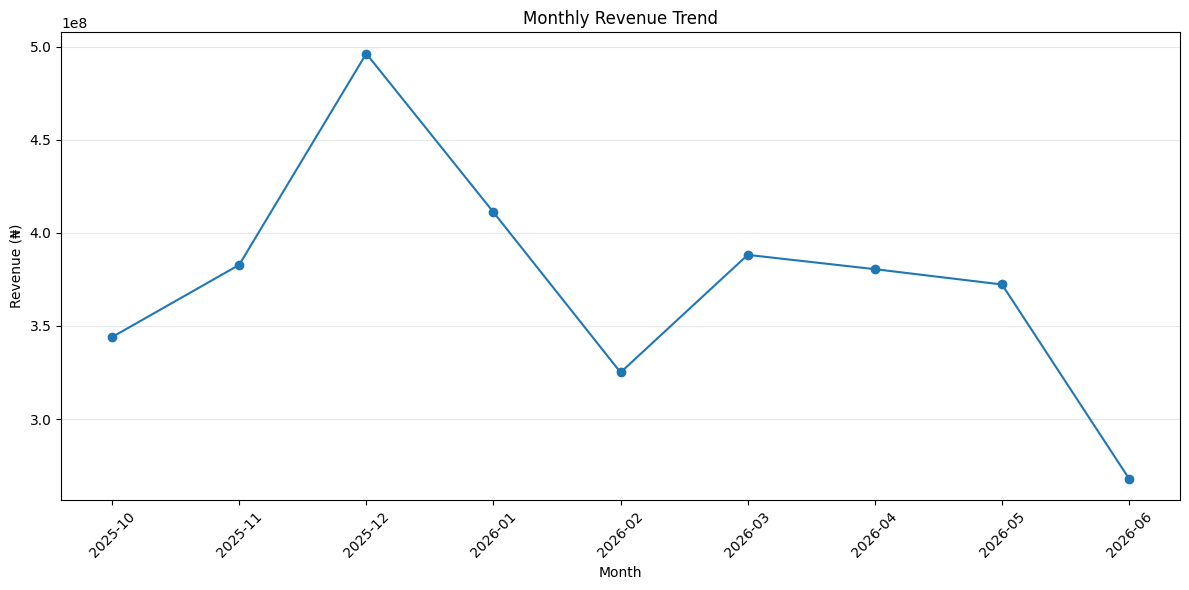

In [33]:



plt.figure(figsize=(12, 6))

plt.plot(
    revenue_trend["year_month"],
    revenue_trend["amount"],
    marker="o"
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue (₦)")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

# Save chart
plt.savefig(
    "Monthly_Revenue_Trend.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [34]:

# Download Saved Charts
from google.colab import files

files.download("Sales_Revenue_by_Division.png")
files.download("Cost_of_Sales_by_Division.png")
files.download("Operating_Expenses_by_Division.png")
files.download("Monthly_Revenue_Trend.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>